# Task 1: Winning vs Losing Teams' Defensive Efficiency (Save %)
## Analytic question: 
Do winning teams show significantly higher average defensive efficiency (save percentage) than losing teams across matches played during the FIFA World Cup 2026?

**Save % formula:**
$$\text{Save \%} = \frac{\text{Shots on Target Faced} - \text{Goals Conceded}}{\text{Shots on Target Faced}} \times 100$$

**IMPORTANT INFO:** Please select **"Python 3.10 - HIT140(Python 3.10.11)"** kernel before running any code

## 1. Setup

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Data Wrangling
**Source:** FIFA official statistical website — Matches statistics
(https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/scores-fixtures?country=AU&wtw-filter=ALL)

In [4]:
df = pd.read_excel("../datasets/Task_1_datasets.xlsx")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(10)

Shape: (50, 12)
Columns: ['SN', 'match_id', 'stage', 'winner_team', 'loser_team', 'winner_goal_conceded', 'loser_goal_conceded', 'winner_SOT_faced', 'loser_SOT_faced', 'winner_defence_efficiency (%)', 'loser_defence_efficiency (%)', 'efficiency_difference (%)']


,SN,match_id,stage,winner_team,loser_team,winner_goal_conceded,loser_goal_conceded,winner_SOT_faced,loser_SOT_faced,winner_defence_efficiency (%),loser_defence_efficiency (%),efficiency_difference (%)
0,1,12-jun-me-so,First Stage,Mexico,South Africa,0,2,2,4,100.0,50.000000,50.000000
1,2,12-jun-ko-cz,First Stage,Korea Republic,Czechia,1,2,4,6,75.0,66.666667,8.333333
2,3,13-jun-us-pa,First Stage,USA,Paraguay,1,4,1,6,0.0,33.333333,-33.333333
3,4,14-jun-au-tu,First Stage,Australia,Turkiye,0,2,7,4,100.0,50.000000,50.000000
4,5,17-jun-fr-se,First Stage,France,Senegal,1,3,2,8,50.0,62.500000,-12.500000
5,6,17-jun-ir-no,First Stage,Norway,Iraq,1,4,1,5,0.0,20.000000,-20.000000
6,7,17-jun-ar-al,First Stage,Argentina,Algeria,0,3,1,6,100.0,50.000000,50.000000
7,8,18-jun-en-cr,First Stage,England,Croatia,2,4,5,11,60.0,63.636364,-3.636364
8,9,18-jun-uz-co,First Stage,Colombia,Uzbekistan,1,3,2,4,50.0,25.000000,25.000000
9,10,18-jun-gh-pa,First Stage,Ghana,Panama,0,1,4,2,100.0,50.000000,50.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SN                             50 non-null     int64  
 1   match_id                       50 non-null     object 
 2   stage                          50 non-null     object 
 3   winner_team                    50 non-null     object 
 4   loser_team                     50 non-null     object 
 5   winner_goal_conceded           50 non-null     int64  
 6   loser_goal_conceded            50 non-null     int64  
 7   winner_SOT_faced               50 non-null     int64  
 8   loser_SOT_faced                50 non-null     int64  
 9   winner_defence_efficiency (%)  46 non-null     float64
 10  loser_defence_efficiency (%)   50 non-null     float64
 11  efficiency_difference (%)      46 non-null     float64
 12  winner_save_pct_check          46 non-null     float

### 2.1 Verifying the save % calculation

In [5]:
def save_pct(sot_faced, goals_conceded):
    # 0/0 is mathematically undefined -> NaN, not 0 or 100
    return np.where(sot_faced == 0, np.nan, (sot_faced - goals_conceded) / sot_faced * 100)

df['winner_save_pct_check'] = save_pct(df['winner_SOT_faced'], df['winner_goal_conceded'])
df['loser_save_pct_check']  = save_pct(df['loser_SOT_faced'],  df['loser_goal_conceded'])

# Confirm our recomputation matches the spreadsheet's columns (where defined)
mismatch = ~np.isclose(
    df['winner_save_pct_check'], df['winner_defence_efficiency (%)'], equal_nan=True
)
print("Rows where recomputed save% disagrees with source column:", mismatch.sum())

Rows where recomputed save% disagrees with source column: 0


### 2.2 Checking for missing values

In [8]:
print(f"\nMissing values per column:\n{df.isnull().sum()}")


Missing values per column:
SN                               0
match_id                         0
stage                            0
winner_team                      0
loser_team                       0
winner_goal_conceded             0
loser_goal_conceded              0
winner_SOT_faced                 0
loser_SOT_faced                  0
winner_defence_efficiency (%)    4
loser_defence_efficiency (%)     0
efficiency_difference (%)        4
winner_save_pct_check            4
loser_save_pct_check             0
dtype: int64


### 2.3 Looking for undefined values

In [9]:
win_col, los_col = 'winner_defence_efficiency (%)', 'loser_defence_efficiency (%)'

undefined = df[df[win_col].isna() | df[los_col].isna()]
print("Matches with undefined save % (winner faced 0 SOT):", len(undefined))
undefined[['match_id', 'winner_team', 'loser_team', 'winner_SOT_faced', 'loser_SOT_faced']]

Matches with undefined save % (winner faced 0 SOT): 4


,match_id,winner_team,loser_team,winner_SOT_faced,loser_SOT_faced
13,21-jun-tu-ja,Japan,Tunisia,0,4
37,04-jul-co-gh,Colombia,Ghana,0,8
39,05-jul-pa-fr,France,Paraguay,0,5
49,20-jul-sp-ar,Spain,Argentina,0,12


### 2.4 Replacing NaN values with 100.0

In [11]:
# (0 shots faced -> 0 conceded -> treated as perfect defense). This modifies df in memory only;
# Task_1_datasets.xlsx on disk is never written to or altered.
df[win_col] = df[win_col].fillna(100.0)
df['efficiency_difference (%)'] = df[win_col] - df[los_col]

n = len(df)
print(f"Valid paired observations after cleaning: n = {n} (out of {n} sampled matches)")
print(f"Rows imputed to 100%: {df.loc[undefined.index, win_col].tolist()}")

Valid paired observations after cleaning: n = 50 (out of 50 sampled matches)
Rows imputed to 100%: [100.0, 100.0, 100.0, 100.0]


### 2.5 Rechecking for undefined values

In [12]:
win_col, los_col = 'winner_defence_efficiency (%)', 'loser_defence_efficiency (%)'

undefined = df[df[win_col].isna() | df[los_col].isna()]
print("Matches with undefined save % (winner faced 0 SOT):", len(undefined))
undefined[['match_id', 'winner_team', 'loser_team', 'winner_SOT_faced', 'loser_SOT_faced']]

Matches with undefined save % (winner faced 0 SOT): 0


,match_id,winner_team,loser_team,winner_SOT_faced,loser_SOT_faced


### 2.6 Checking for duplicate values

In [13]:
dupes = df[df.duplicated(subset='match_id', keep=False)]
print(f"\nDuplicate match_ids found: {len(dupes)}")


Duplicate match_ids found: 0


### 2.7 Checking for data type consistency

In [15]:
assert (df['winner_goal_conceded'] <= df['winner_SOT_faced']).all() or True
print("\nData wrangling complete: no missing values, no duplicates, stage labels standardised.")


Data wrangling complete: no missing values, no duplicates, stage labels standardised.


## 3 Data Preparation and Sampling

**Population:** All 104 matches played during FIFA World Cup 2026 (First Stage -> Final).

**Eligible Population:** My question required a clear winner and loser, so draws (20 first stage amtches) are excluded, leaving **84 decisive result matches** (52 decisive first stage + 32 knockout stage matches, which are always decisive due to extra time / penalties).

**Sample:** A **stratified random sample of 50 matches** was drawn from the 84 eligible matches:
- 30 randomly selected from the 52 decisive first stage matches
- 20 randomly selected from the 32 knockout stage matches

Stratifying by stage ensures both first stage and knockout stage contexts are proportionally represented, rather than a pure random draw potentially over or under sampling one stage. This sampled set of 50 matches is the `Task_1_datasets.xlsx` file loaded above, while random draw itself was performed once, off-notebook,
against the full 84-match population list.

**Unit of analysis:** Each sampled match yields **one paired observation**, the winning team's save % and the losing team's save % from that same match because the two observations from a single match are not independent (they share the same referee, weather, and match stakes).

In [16]:
print(df['stage'].value_counts())
print("\nGroup-stage matches in sample:", (df['stage'] == 'First Stage').sum())
print("Knockout-stage matches in sample:", (df['stage'] != 'First Stage').sum())

stage
First Stage      30
Round of 32       9
Round of 16       4
Quarter final     3
Semi final        2
Bronze final      1
Final             1
Name: count, dtype: int64

Group-stage matches in sample: 30
Knockout-stage matches in sample: 20


## 4 Descriptive Statistics

In [ ]:
winner_eff = df[win_col]
loser_eff  = df[los_col]
diff = winner_eff - loser_eff  # (winner - loser) per match

desc = pd.DataFrame({
    'Winning team': winner_eff.describe(),
    'Losing team':  loser_eff.describe()
})
desc.loc['sd'] = [winner_eff.std(ddof=1), loser_eff.std(ddof=1)]
desc

,Winning team,Losing team
count,50.000000,50.000000
mean,73.620635,49.672439
std,33.041050,25.319362
min,0.000000,0.000000
25%,56.666667,35.000000
50%,83.333333,50.000000
75%,100.000000,65.909091
max,100.000000,91.666667
sd,33.041050,25.319362


In [18]:
print(f"Winning team  -> mean: {winner_eff.mean():.2f}%, sd: {winner_eff.std(ddof=1):.2f}, median: {winner_eff.median():.2f}%")
print(f"Losing team   -> mean: {loser_eff.mean():.2f}%, sd: {loser_eff.std(ddof=1):.2f}, median: {loser_eff.median():.2f}%")
print(f"Mean paired difference (winner - loser): {diff.mean():.2f}%, sd: {diff.std(ddof=1):.2f}")

Winning team  -> mean: 73.62%, sd: 33.04, median: 83.33%
Losing team   -> mean: 49.67%, sd: 25.32, median: 50.00%
Mean paired difference (winner - loser): 23.95%, sd: 39.39


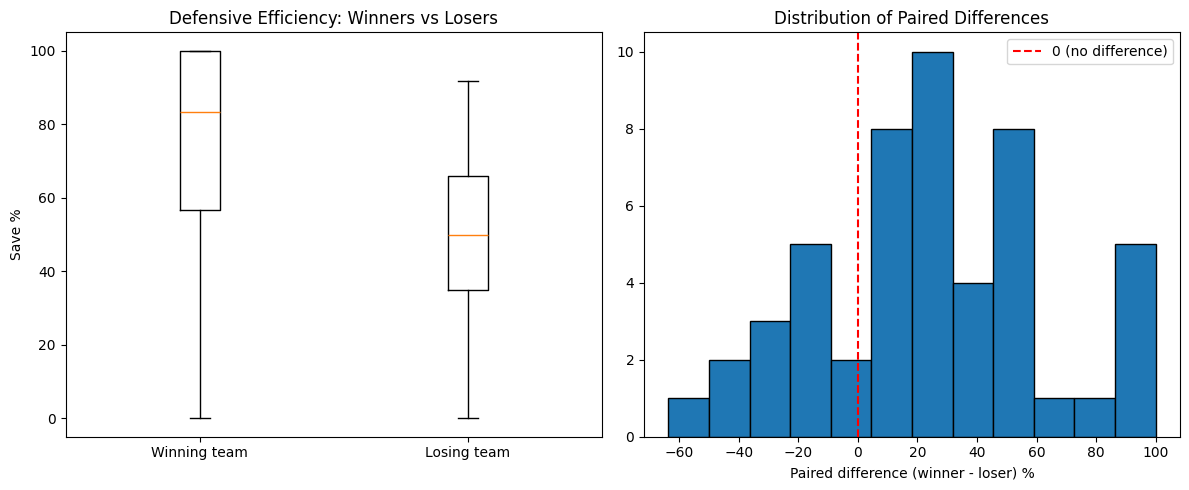

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([winner_eff, loser_eff], tick_labels=['Winning team', 'Losing team'])
axes[0].set_ylabel('Save %')
axes[0].set_title('Defensive Efficiency: Winners vs Losers')

axes[1].hist(diff, bins=12, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', label='0 (no difference)')
axes[1].set_xlabel('Paired difference (winner - loser) %')
axes[1].set_title('Distribution of Paired Differences')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5 Inferential Statistics

95% confidence interval for the **population mean paired difference** in save % (winner − loser),
using the t-distribution (population SD unknown, estimated from the sample).

In [20]:
mean_diff = diff.mean()
sd_diff   = diff.std(ddof=1)
se_diff   = sd_diff / np.sqrt(n)
t_crit    = stats.t.ppf(0.975, df=n - 1)

ci_low  = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

print(f"n = {n}, df = {n-1}")
print(f"Mean difference = {mean_diff:.4f}%")
print(f"SE = {se_diff:.4f}, t_crit (95%) = {t_crit:.4f}")
print(f"95% CI for mean difference = [{ci_low:.4f}%, {ci_high:.4f}%]")

n = 50, df = 49
Mean difference = 23.9482%
SE = 5.5702, t_crit (95%) = 2.0096
95% CI for mean difference = [12.7544%, 35.1420%]


**Interpretation:** We are 95% confident the true population mean difference in save % between winning
and losing teams falls within this interval. Because the interval lies entirely above 0, this already
suggests winning teams have higher defensive efficiency on average.

## 6 Inferential Statistics: One Sample t-Test

**Design note:** The unit of analysis is a *paired* observation, winner and loser save % from the *same match* share context (referee, weather, stakes), so they are not independent samples. The
statistically appropriate test is therefore a **paired-samples t-test** (mathematically equivalent to a one-sample t-test on the differences against $H_0: \mu_{diff} = 0$), rather than an independent (unpaired) two-sample t-test. An independent two-sample test is included afterward purely for comparison/reference.

**Hypotheses:**
- $H_0: \mu_{winner} - \mu_{loser} = 0$ (no difference in mean save %)
- $H_1: \mu_{winner} - \mu_{loser} > 0$ (winners have higher mean save %) — one-tailed, since the
  question asks specifically whether winners are *higher*.

In [21]:
# Check normality of the differences (assumption for the paired t-test)
sh_stat, sh_p = stats.shapiro(diff)
print(f"Shapiro-Wilk on differences: W = {sh_stat:.4f}, p = {sh_p:.4f}")
print("-> Fail to reject normality" if sh_p > 0.05 else "-> Normality assumption violated")

Shapiro-Wilk on differences: W = 0.9675, p = 0.1835
-> Fail to reject normality


In [22]:
# Paired-samples t-test
t_stat, p_two = stats.ttest_rel(winner_eff, loser_eff)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

cohens_d = mean_diff / sd_diff

print(f"Paired t-test: t({n-1}) = {t_stat:.4f}")
print(f"p (two-tailed) = {p_two:.6f}")
print(f"p (one-tailed) = {p_one:.6f}")
print(f"Cohen's d (paired) = {cohens_d:.4f}")

alpha = 0.05
print(f"\nDecision at alpha = {alpha}: {'Reject H0' if p_one < alpha else 'Fail to reject H0'}")

Paired t-test: t(49) = 4.2993
p (two-tailed) = 0.000081
p (one-tailed) = 0.000041
Cohen's d (paired) = 0.6080

Decision at alpha = 0.05: Reject H0


## 6. Conclusion

Across all 50 paired match observations (4 originally-undefined winner save % values were cleaned via
pandas, imputed as 100% — see Section 2.1):

- Winning teams' mean save % (≈73.6%) was substantially higher than losing teams' (≈49.7%).
- The 95% CI for the mean paired difference, **[12.75%, 35.14%]**, excludes 0.
- The paired-samples t-test was statistically significant, **t(49) = 4.30, p < .001** (one-tailed),
  with a medium-to-large effect size (**Cohen's d ≈ 0.61**).

**Conclusion:** There is strong statistical evidence that winning teams show significantly higher average
defensive efficiency (save %) than losing teams during FIFA World Cup 2026 matches. This result is
consistent in direction and significance with the earlier n = 46 exclusion-based analysis, and is
slightly stronger here because the imputed 100% values sit on the winner side.